### Loading Dataset from Kegal

In [200]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

filePath = "Salary_Data.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, "mohithsairamreddy/salary-data", filePath
)
print(df.info())
print(df.describe())
print(f"Shape: {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
None
               Age  Years of Experience         Salary
count  6702.000000          6701.000000    6699.000000
mean     33.620859             8.094687  115326.964771
std       7.614633             6.059003   52786.183911
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            12.000000  160000.000000
max      6

MISSING VALUE ANALYSIS
                                 Feature  Missing_Count  Missing_Percentage  \
Age                                  Age              2                0.03   
Gender                            Gender              2                0.03   
Education Level          Education Level              3                0.04   
Job Title                      Job Title              2                0.03   
Years of Experience  Years of Experience              3                0.04   
Salary                            Salary              5                0.07   

                    Data_Type  
Age                   float64  
Gender                    str  
Education Level           str  
Job Title                 str  
Years of Experience   float64  
Salary                float64  

Total missing values: 17


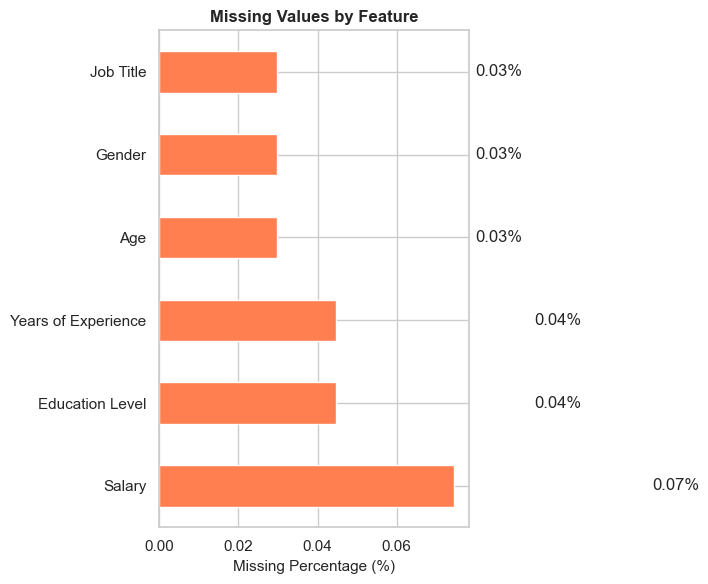

In [201]:
# Missing Value Analysis
print("MISSING VALUE ANALYSIS")
print("=" * 40)
missing_data = pd.DataFrame(
    {
        'Feature': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'Data_Type': df.dtypes,
    }
)
print(missing_data)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)', fontsize=11)
ax.set_title('Missing Values by Feature', fontsize=12, fontweight='bold')
for i, v in enumerate(missing_pct[missing_pct > 0]):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()

In [202]:
# Redefining column names
df.rename(
    columns={
        'Years of Experience': 'Experience',
        "Education Level": 'Education',
        'Job Title': 'Job',
    },
    inplace=True,
)
print(df.columns)

# Convert numeric columns to appropriate data types
for col in ['Age', 'Experience', 'Salary']:
    df[col] = (
        pd.to_numeric(df[col], errors='coerce', downcast='integer')
        .fillna(df[col].mean())
        .abs()
    )
# convert categorical columns to string type
for col in ['Education', 'Job', 'Gender']:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.info())

Index(['Age', 'Gender', 'Education', 'Job', 'Experience', 'Salary'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         6704 non-null   float64
 1   Gender      6704 non-null   str    
 2   Education   6704 non-null   str    
 3   Job         6704 non-null   str    
 4   Experience  6704 non-null   float64
 5   Salary      6704 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
None


CATEGORICAL FEATURES ANALYSIS
Categorical features: ['Gender', 'Education', 'Job']
Numeric features: ['Age', 'Experience', 'Salary']

Gender - Value Counts:
Gender
male      3676
female    3014
other       14
Name: count, dtype: int64
Unique values: 3

Education - Value Counts:
Education
bachelor's degree    2270
master's degree      1573
phd                  1369
bachelor's            756
high school           448
master's              288
Name: count, dtype: int64
Unique values: 6

Job - Value Counts:
Job
software engineer                520
data scientist                   453
software engineer manager        376
data analyst                     363
senior project engineer          318
                                ... 
junior operations coordinator      1
junior financial advisor           1
developer                          1
social m                           1
social media man                   1
Name: count, Length: 192, dtype: int64
Unique values: 192


C:\Users\ASHAR\AppData\Local\Temp\ipykernel_9524\956188238.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


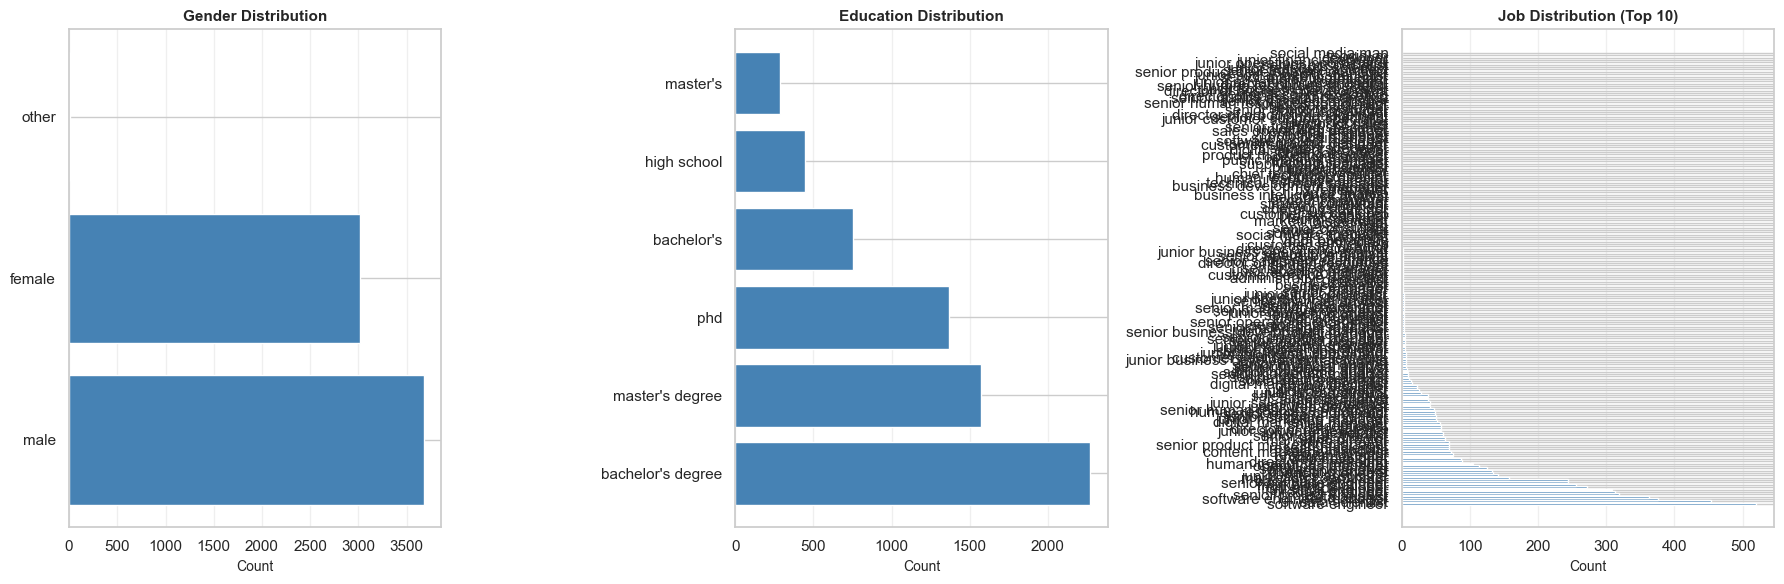

In [203]:
# Categorical Features Analysis


print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

categorical_features = df.select_dtypes(
    include=[
        'object',
        'category',
    ]
).columns.tolist()

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Categorical features: {categorical_features}")
print(f"Numeric features: {numeric_features}")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, feature in enumerate(categorical_features):
    print(f"\n{feature} - Value Counts:")
    vc = df[feature].value_counts(dropna=False)
    print(vc)
    print(f"Unique values: {df[feature].nunique()}")

    plot_data = vc
    axes[idx].barh(range(len(plot_data)), plot_data.values, color='steelblue')
    axes[idx].set_yticks(range(len(plot_data)))
    axes[idx].set_yticklabels(plot_data.index)
    axes[idx].set_xlabel('Count', fontsize=10)
    axes[idx].set_title(
        f'{feature} Distribution' + (' (Top 10)' if feature == 'Job' else ''),
        fontsize=11,
        fontweight='bold',
    )
    axes[idx].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

CATEGORICAL FEATURES vs SALARY RELATIONSHIP

Mean Salary by Gender:
             mean    median  count       std
Gender                                      
other   125869.86  158610.0     14  44242.38
male    121383.27  120000.0   3676  52064.75
female  107891.47  105000.0   3014  52715.03

Mean Salary by Education:
                        mean    median  count       std
Education                                              
phd                165651.46  170000.0   1369  34339.75
master's           157604.17  177500.0    288  39864.27
master's degree    125069.14  122000.0   1573  38720.94
bachelor's         124767.66  130000.0    756  46697.56
bachelor's degree   85234.55   75000.0   2270  38367.18
high school         36706.69   30000.0    448  22549.13

Mean Salary by Job:
                                         mean    median  count       std
Job                                                                     
ceo                                 250000.00  250000.0      1   

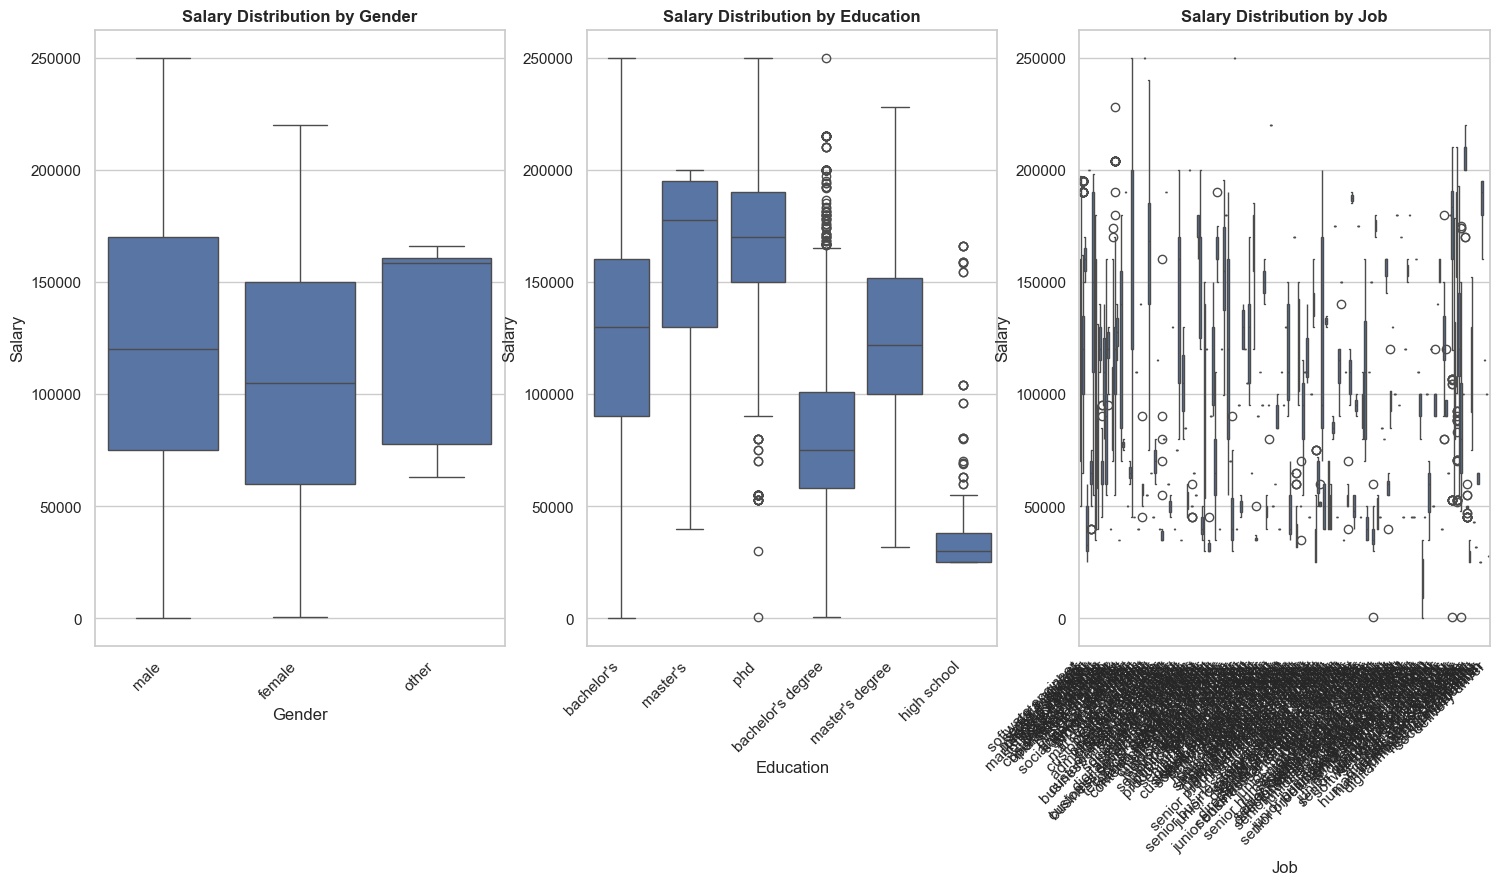

In [204]:
# Categorical Features vs Target (Salary) Analysis
print("CATEGORICAL FEATURES vs SALARY RELATIONSHIP")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, feature in enumerate(categorical_features):
    print(f"\nMean Salary by {feature}:")
    salary_by_cat = (
        df.groupby(feature)['Salary'].agg(['mean', 'median', 'count', 'std']).round(2)
    )
    salary_by_cat = salary_by_cat.sort_values('mean', ascending=False)
    print(salary_by_cat)

    # Box plot
    sns.boxplot(x=feature, y='Salary', data=df, ax=axes[idx])
    axes[idx].set_title(f'Salary Distribution by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Salary')
    plt.sca(axes[idx])
    plt.xticks(rotation=45, ha='right')
plt.suptitle('')  # Remove default title
plt.show()

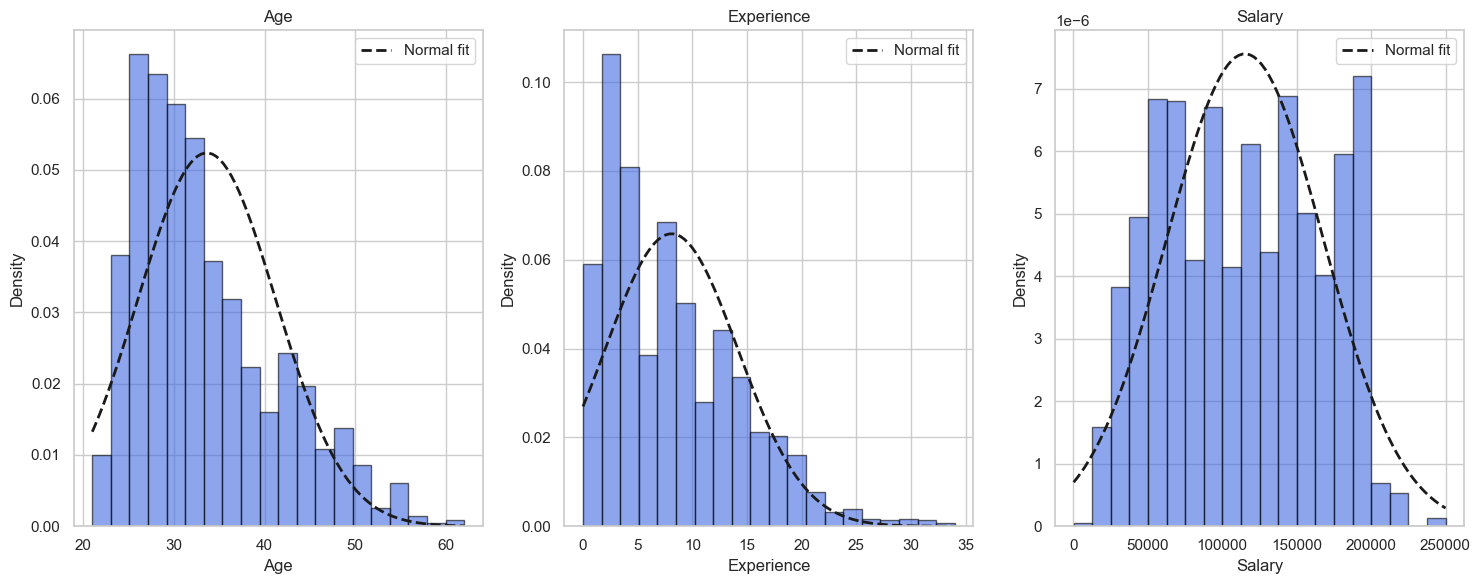

In [205]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for idx, col in enumerate(numeric_features):
    axes[idx].hist(
        df[col], bins=20, density=True, alpha=0.6, color='royalblue', edgecolor='black'
    )
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    # Calculate and plot normal distribution curve
    mu = df[col].mean()
    sigma = df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 100)
    # using formula for normal dist
    y = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    axes[idx].plot(x, y, 'k--', linewidth=2, label='Normal fit')
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')  # Changed from 'Frequency' to 'Density'
    axes[idx].legend()
plt.tight_layout()


OUTLIER DETECTION - IQR METHOD

Age:
  Q1: 28.00, Q3: 38.00, IQR: 10.00
  Lower Bound: 13.00, Upper Bound: 53.00
  Outliers: 123 (1.83%)
  Outlier Range: [21.00, 62.00]

Experience:
  Q1: 3.00, Q3: 12.00, IQR: 9.00
  Lower Bound: -10.50, Upper Bound: 25.50
  Outliers: 75 (1.12%)
  Outlier Range: [0.00, 34.00]

Salary:
  Q1: 70000.00, Q3: 160000.00, IQR: 90000.00
  Lower Bound: -65000.00, Upper Bound: 295000.00
  Outliers: 0 (0.00%)
  Outlier Range: [350.00, 250000.00]


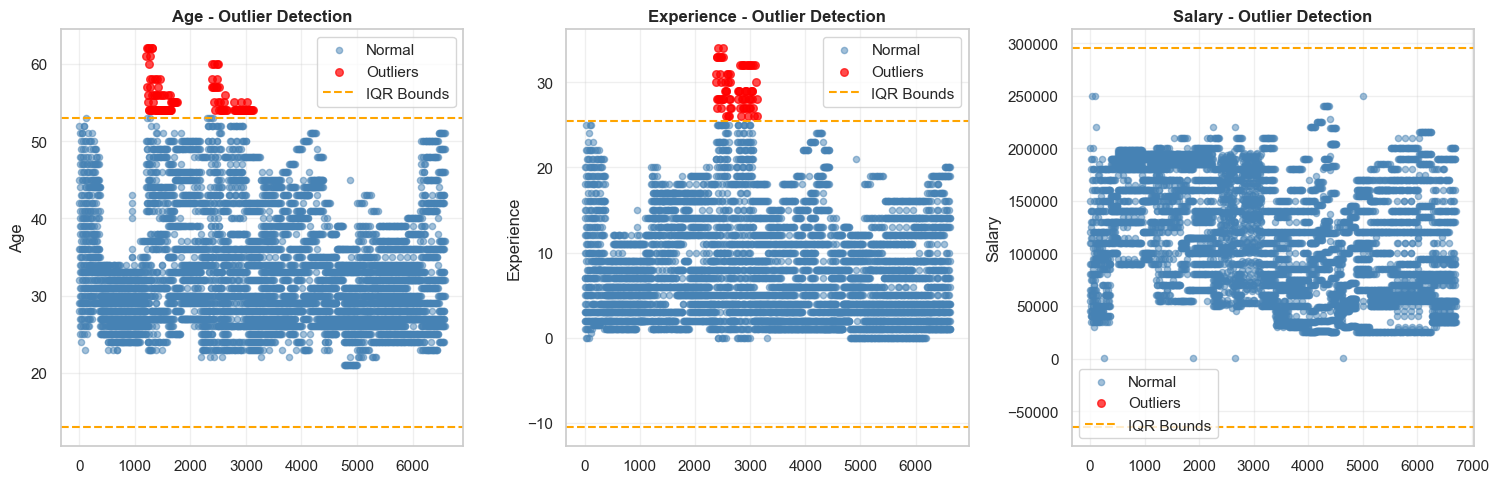


Outlier Summary:
   Feature  Lower_Bound  Upper_Bound  Outliers_Count  Outliers_Pct
       Age         13.0         53.0             123      1.834726
Experience        -10.5         25.5              75      1.118735
    Salary     -65000.0     295000.0               0      0.000000


In [206]:
# Outlier Detection using IQR Method
print("\n" + "=" * 60)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 60)
outlier_summary = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, feature in enumerate(numeric_features):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100

    print(f"\n{feature}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}%)")
    print(f"  Outlier Range: [{df[feature].min():.2f}, {df[feature].max():.2f}]")

    outlier_summary.append(
        {
            'Feature': feature,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outliers_Count': len(outliers),
            'Outliers_Pct': outlier_pct,
        }
    )

    # Scatter plot showing outliers
    non_outliers = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    axes[idx].scatter(
        range(len(non_outliers)),
        non_outliers[feature],
        alpha=0.5,
        s=20,
        label='Normal',
        color='steelblue',
    )
    axes[idx].scatter(
        outliers.index,
        outliers[feature],
        alpha=0.7,
        s=30,
        label='Outliers',
        color='red',
    )
    axes[idx].axhline(lower_bound, color='orange', linestyle='--', label='IQR Bounds')
    axes[idx].axhline(upper_bound, color='orange', linestyle='--')
    axes[idx].set_ylabel(feature)
    axes[idx].set_title(f'{feature} - Outlier Detection', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOutlier Summary:")
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

In [207]:
# handling dublicate values
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(
    f"Shape before removing duplicates: {df.shape} after removing duplicates: {df_clean.shape}"
)

Shape before removing duplicates: (6704, 6) after removing duplicates: (1792, 6)



------------------------------------------------------------
SALARY STATISTICS - AFTER REMOVING DUPLICATES
------------------------------------------------------------
count      1792.000000
mean     113182.084185
std       51525.505743
min         350.000000
25%       70000.000000
50%      110000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

------------------------------------------------------------
IMPACT ANALYSIS
------------------------------------------------------------
Mean salary change: $2,144.88
Median salary change: $5,000.00
Std salary change: $1,240.99


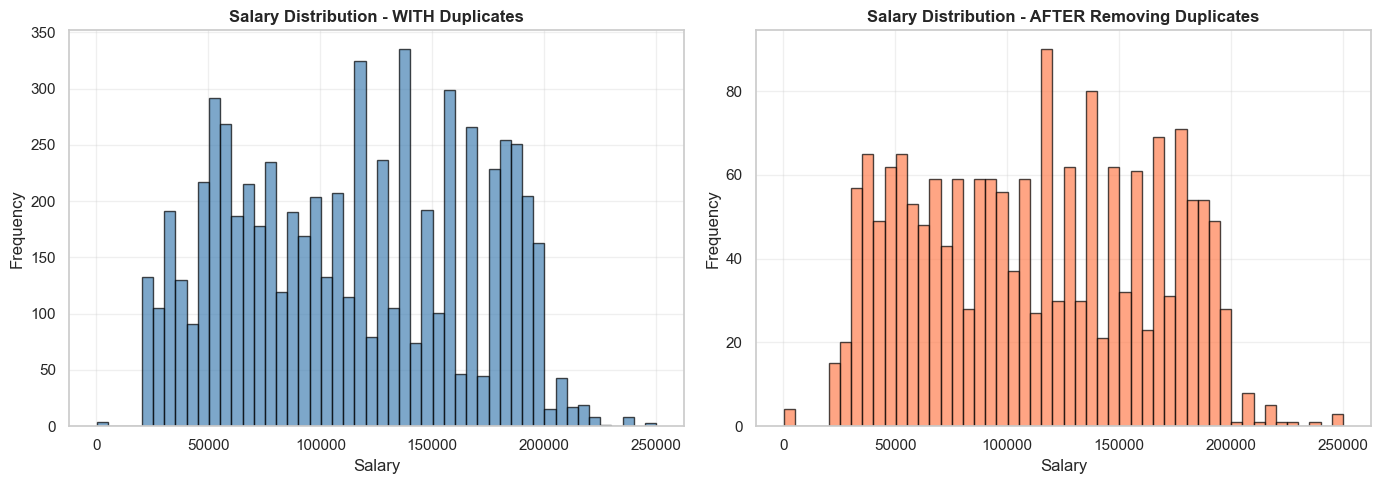


⚠️ Note: Removing 73% of data may affect model performance. Duplicates likely represent repeated records.
Consider keeping duplicates if they represent legitimate data points (e.g., same person at different times).


In [208]:
# Duplicate Impact Analysis - Comparison
print("\n" + "-" * 60)
print("SALARY STATISTICS - AFTER REMOVING DUPLICATES")
print("-" * 60)
salary_stats_after = df_clean['Salary'].describe()
print(salary_stats_after)

print("\n" + "-" * 60)
print("IMPACT ANALYSIS")
print("-" * 60)
print(f"Mean salary change: ${df['Salary'].mean() - df_clean['Salary'].mean():,.2f}")
print(
    f"Median salary change: ${df['Salary'].median() - df_clean['Salary'].median():,.2f}"
)
print(f"Std salary change: ${df['Salary'].std() - df_clean['Salary'].std():,.2f}")

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(
    df['Salary'].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black'
)
axes[0].set_title(
    'Salary Distribution - WITH Duplicates', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    df_clean['Salary'].dropna(), bins=50, alpha=0.7, color='coral', edgecolor='black'
)
axes[1].set_title(
    'Salary Distribution - AFTER Removing Duplicates', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "\n⚠️ Note: Removing 73% of data may affect model performance. Duplicates likely represent repeated records."
)
print(
    "Consider keeping duplicates if they represent legitimate data points (e.g., same person at different times)."
)

<Figure size 300x100 with 0 Axes>

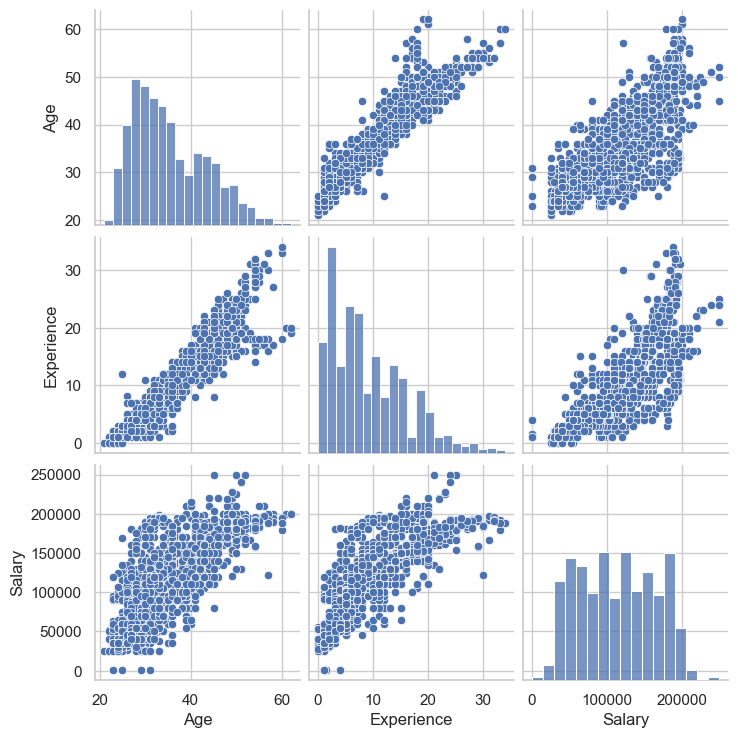

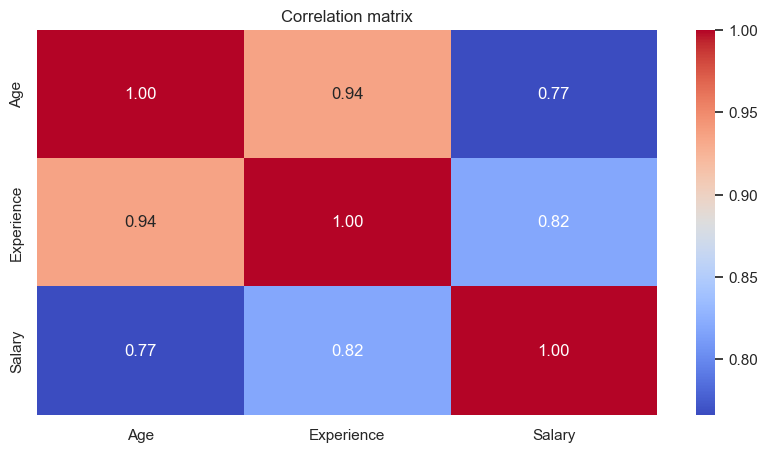

In [209]:
# Pairplot to see relationships

plt.figure(figsize=(3, 1))
sns.pairplot(df_clean[numeric_features])
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    df_clean[numeric_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation matrix")
plt.show()

#### strong correlations among these variables experience and age are highly correlated, both relate to salary, which can create multicollinearity issues in linear regression

In [210]:
# creating pipelines

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

age_pipeline = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)
##for experience
log_transform = FunctionTransformer(func=np.log1p, validate=False)
skewed_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('log', log_transform),
        ('scaler', StandardScaler()),
    ]
)
gender_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary")),
    ]
)
edu_order = [
    "primary",  # lowest
    "high school",
    "diploma",
    "bachelors",
    "masters",
    "phd",
]
education_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "oridnal",
            OrdinalEncoder(
                categories=[edu_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

job_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                drop="first", handle_unknown="infrequent_if_exist", sparse_output=False
            ),
        ),
    ]
)

In [211]:
age = ['Age']
education = ['Education']
gender = ['Gender']
skewed = ['Experience']
job = ['Job']
preprocessor = ColumnTransformer(
    transformers=[
        ("age", age_pipeline, age),
        ("education", education_pipeline, education),
        ("gender", gender_pipeline, gender),
        ('skewed', skewed_pipeline, skewed),
        ('job', job_pipeline, job),
    ]
)

# log transformation to handle skewness in salary
df_clean['log_salary'] = np.log1p(df_clean['Salary'])

X = df_clean[['Age', 'Gender', 'Education', 'Job', 'Experience']]
Y = df_clean['log_salary']
print(Y.isna().sum())
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"x-train:{X_train.shape}, x-test:{X_test.shape}")
print(f"Y-train:{Y_train.shape}, x-test:{Y_test.shape}")

0
x-train:(1433, 5), x-test:(359, 5)
Y-train:(1433,), x-test:(359,)


In [212]:
from matplotlib.pyplot import grid
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

Linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("linear", LinearRegression()),
    ]
)
param_grid = {
    'PolynomialFeatures__degree': [1, 2],
    'Ridge__alpha': [0.1, 1, 1.8307, 10, 100],
}

Polynomial_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("PolynomialFeatures", PolynomialFeatures(include_bias=False)),
        ("Ridge", Ridge()),
    ]
)
grid = GridSearchCV(
    Polynomial_model, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2
)
Linear_model.fit(X_train, Y_train)
grid.fit(X_train, Y_train)

y_predict_li = Linear_model.predict(X_test)
y_predict_gd = grid.predict(X_test)
print(f"Linear R2: {r2_score(Y_test, y_predict_li):.3f} ")
print(f"Linear MAE: {mean_absolute_error(Y_test, y_predict_li):.3f}")
print(f"Linear MSE: {mean_squared_error(Y_test, y_predict_li):.3f}")
print(f"Linear RMSE: {root_mean_squared_error(Y_test, y_predict_li):.3f}")
print("-" * 30)

print(f"GridSearchCV R2: {r2_score(Y_test, y_predict_gd):.3f} ")
print(f"GridSearchCV MAE: {mean_absolute_error(Y_test, y_predict_gd):.3f}")
print(f"GridSearchCV RMSE: {root_mean_squared_error(Y_test, y_predict_gd):.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Linear R2: 0.896 
Linear MAE: 0.127
Linear MSE: 0.027
Linear RMSE: 0.164
------------------------------
GridSearchCV R2: 0.914 
GridSearchCV MAE: 0.112
GridSearchCV RMSE: 0.149


c:\Projects\Python\python practice code\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
c:\Projects\Python\python practice code\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [213]:
print("-" * 30)
sample = pd.DataFrame(
    [
        {
            "Age": 30,
            "Gender": "male",
            "Education": "bachelor's",
            "Job": "software engineer",
            "Experience": 5,
        }
    ]
)

# Predict log-salary, then convert to Salary
sample_log_pred = Linear_model.predict(sample)[0]
sample_salary_pred = np.expm1(sample_log_pred)


print(f"Predicted Salary for sample Linear Regression: ${sample_salary_pred:,.2f}")

print(
    f"Predicted Salary for sample GridSearchCV: ${np.expm1(grid.predict(sample)[0]):,.2f}"
)
print("-" * 30)

------------------------------
Predicted Salary for sample Linear Regression: $107,027.25
Predicted Salary for sample GridSearchCV: $106,803.59
------------------------------


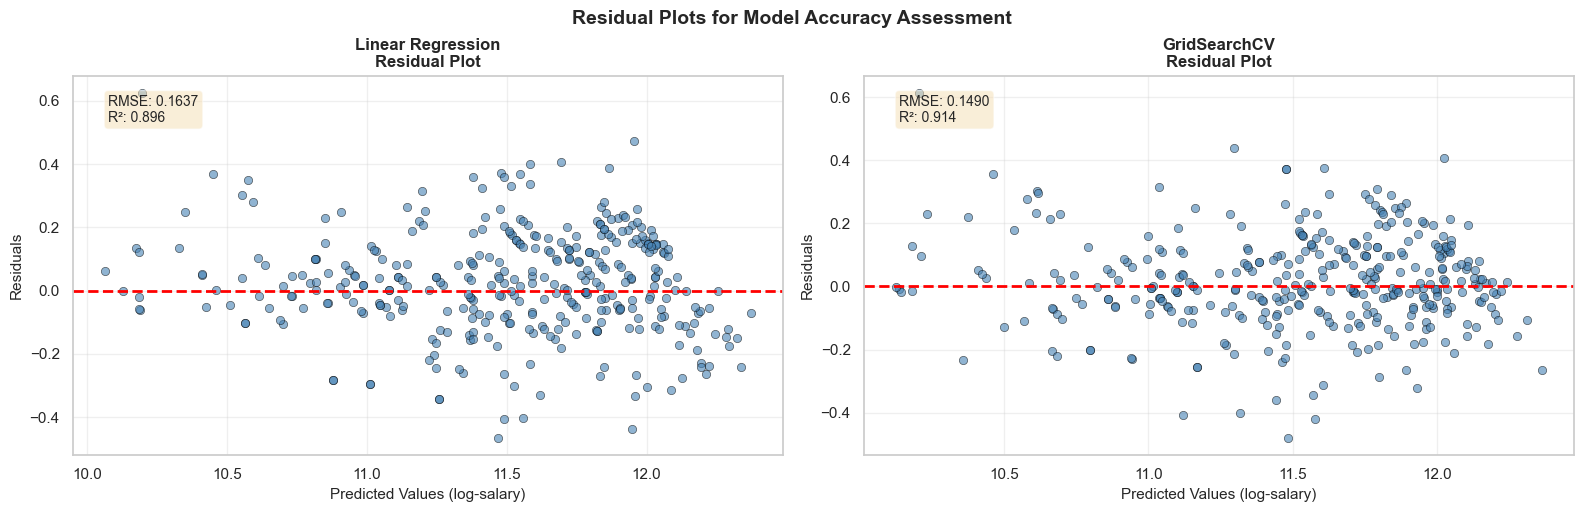


RESIDUAL ANALYSIS - MODEL ACCURACY

Linear Regression:
  Mean of residuals: 0.024029 (should be close to 0)
  Std of residuals: 0.162132
  Min residual: -0.465951
  Max residual: 0.624988

GridSearchCV:
  Mean of residuals: 0.016012 (should be close to 0)
  Std of residuals: 0.148317
  Min residual: -0.480325
  Max residual: 0.613199


In [214]:
# Residual Plot - Model Accuracy Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Calculate residuals for each model
residuals_linear = Y_test - y_predict_li
residuals_poly = Y_test - y_predict_gd

models = ['Linear Regression', 'GridSearchCV']
predictions = [y_predict_li, y_predict_gd]
residuals_list = [residuals_linear, residuals_poly]

# Plot residuals vs predicted values
for idx, (ax, model_name, y_pred, residuals) in enumerate(
    zip(axes, models, predictions, residuals_list)
):
    ax.scatter(
        y_pred,
        residuals,
        alpha=0.6,
        color='steelblue',
        edgecolor='black',
        linewidth=0.5,
    )
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Values (log-salary)', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'{model_name}\nResidual Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Calculate and display RMSE and R2 for reference
    rmse = root_mean_squared_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    ax.text(
        0.05,
        0.95,
        f'RMSE: {rmse:.4f}\nR²: {r2:.3f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10,
    )

plt.tight_layout()
plt.suptitle(
    'Residual Plots for Model Accuracy Assessment',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.show()

print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS - MODEL ACCURACY")
print("=" * 60)
for model_name, residuals in zip(models, residuals_list):
    print(f"\n{model_name}:")
    print(f"  Mean of residuals: {residuals.mean():.6f} (should be close to 0)")
    print(f"  Std of residuals: {residuals.std():.6f}")
    print(f"  Min residual: {residuals.min():.6f}")
    print(f"  Max residual: {residuals.max():.6f}")

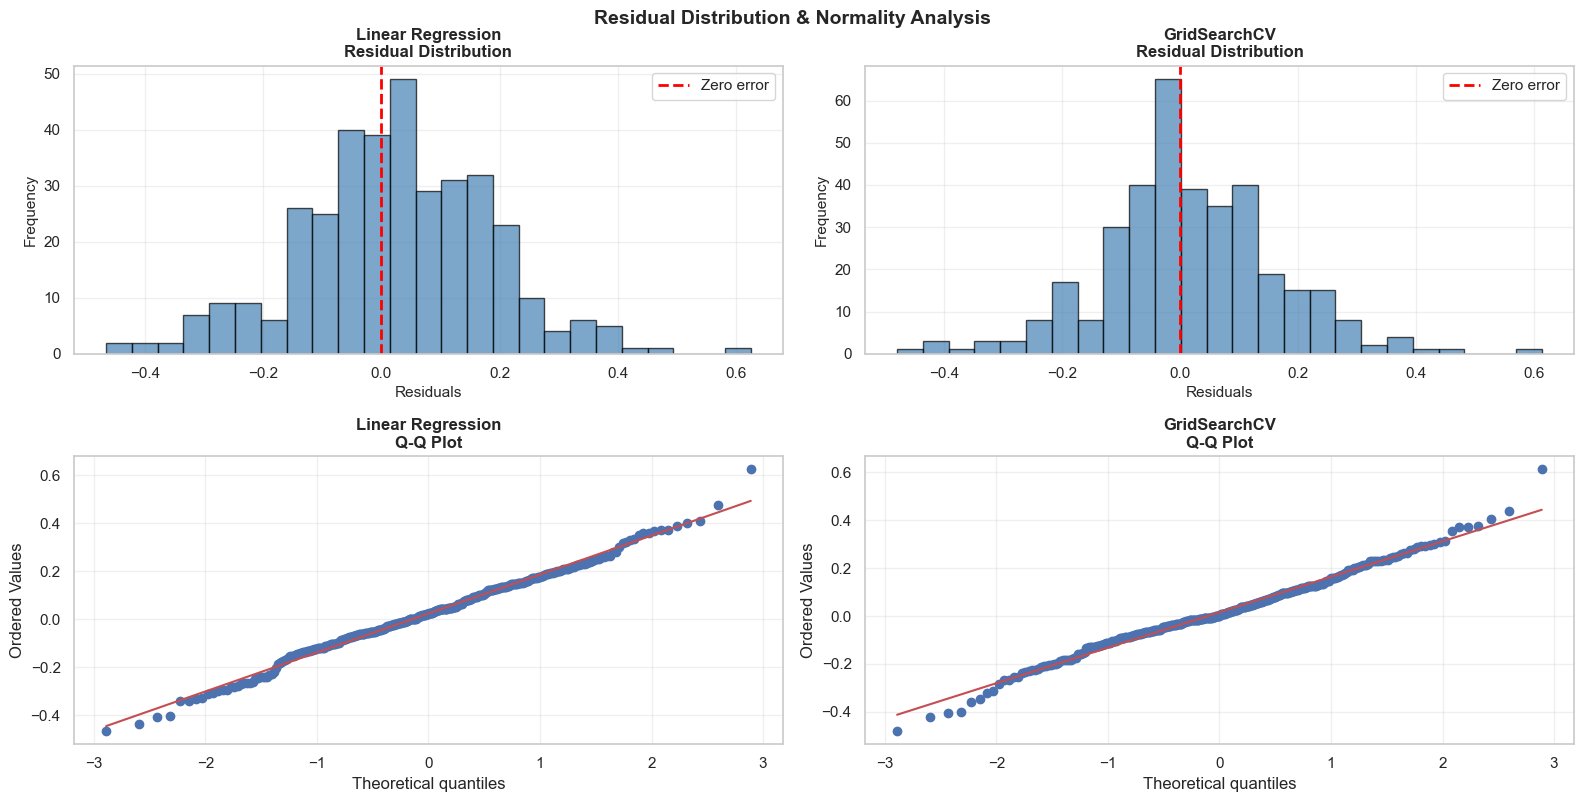


NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)
H0: Residuals are normally distributed
If p-value > 0.05, residuals are likely normally distributed

Linear Regression:
  Test Statistic: 0.993709
  P-value: 0.142013
  Result: Residuals are normally distributed ✓

GridSearchCV:
  Test Statistic: 0.989160
  P-value: 0.009145
  Result: Residuals deviate from normality



In [215]:
# Residual Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for idx, (model_name, residuals) in enumerate(zip(models, residuals_list)):
    # Histogram
    ax_hist = axes[0, idx]
    ax_hist.hist(residuals, bins=25, alpha=0.7, color='steelblue', edgecolor='black')
    ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
    ax_hist.set_xlabel('Residuals', fontsize=11)
    ax_hist.set_ylabel('Frequency', fontsize=11)
    ax_hist.set_title(
        f'{model_name}\nResidual Distribution', fontsize=12, fontweight='bold'
    )
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # Q-Q Plot (to check normality)
    from scipy import stats

    ax_qq = axes[1, idx]
    stats.probplot(residuals, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{model_name}\nQ-Q Plot', fontsize=12, fontweight='bold')
    ax_qq.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(
    'Residual Distribution & Normality Analysis', fontsize=14, fontweight='bold', y=1.00
)
plt.show()

print("\n" + "=" * 60)
print("NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)")
print("=" * 60)
print("H0: Residuals are normally distributed")
print("If p-value > 0.05, residuals are likely normally distributed\n")

for model_name, residuals in zip(models, residuals_list):
    stat, p_value = stats.shapiro(residuals)
    print(f"{model_name}:")
    print(f"  Test Statistic: {stat:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(
        f"  Result: {'Residuals are normally distributed ✓' if p_value > 0.05 else 'Residuals deviate from normality'}\n"
    )